# Part 05 - CLV Business Strategy & Final Executive Report

This notebook turns the final CLV predictions and customer value segments into practical business strategies.

The goal is to identify where the company should focus retention, marketing, reactivation, and customer development efforts.

## 1. Load the Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Final CLV Predictions

Part 05 starts from the customer scoring output created in Part 04.

This file contains the actual future value, predicted future value, and customer value segment for each customer.

In [2]:
prediction_path = "../data/processed/customer_clv_predictions.csv"

customer_predictions = pd.read_csv(
    prediction_path
)

customer_predictions.head()

,CustomerID,Future_90d_Value,Predicted_90d_Value,Value_Segment
0,12346,0.00,4265.083051,VIP
1,12347,1519.14,964.801316,High
2,12348,310.00,383.319711,Medium
3,12349,1757.55,751.823231,High
4,12350,0.00,91.713395,Low


### 2.1 Load Customer Behaviour Data

In [3]:
customer_data_path = "../data/processed/customer_clv_dataset.csv"

customer_data = pd.read_csv(
    customer_data_path,
    parse_dates=[
        "first_purchase_date",
        "last_purchase_date"
    ]
)

customer_data.head()

,CustomerID,first_purchase_date,last_purchase_date,Recency,Tenure_days,Tenure_months,active_days,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,ProductDiversity,Future_90d_Orders,Future_90d_Value
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,235,635,21.2,636,12,77556.46,6463.038333,0.018868,27,0,0.00
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,39,313,10.4,314,6,3402.39,567.065000,0.019108,107,2,1519.14
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,158,347,11.6,348,4,1709.40,427.350000,0.011494,25,1,310.00
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,317,498,16.6,499,3,2671.14,890.380000,0.006012,90,1,1757.55
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,219,219,7.3,220,1,334.40,334.400000,0.004545,17,0,0.00


### 2.2 Basic Dataset Check

In [4]:
customer_predictions.shape

(5281, 4)

In [5]:
customer_predictions.dtypes

CustomerID               int64
Future_90d_Value       float64
Predicted_90d_Value    float64
Value_Segment           object
dtype: object

In [6]:
customer_predictions.isnull().sum()

CustomerID             0
Future_90d_Value       0
Predicted_90d_Value    0
Value_Segment          0
dtype: int64

In [7]:
customer_predictions["CustomerID"].nunique()

5281

In [8]:
customer_data.shape

(5281, 14)

## 3. Check the Final Customer Segments

In [9]:
segment_counts = (
    customer_predictions["Value_Segment"]
    .value_counts()
    .sort_index()
)

segment_counts

Value_Segment
High       792
Low       2641
Medium    1584
VIP        264
Name: count, dtype: int64

In [10]:
segment_percentage = (
    customer_predictions["Value_Segment"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

segment_percentage.round(2)

Value_Segment
High      15.00
Low       50.01
Medium    29.99
VIP        5.00
Name: proportion, dtype: float64

## 4. Executive CLV Snapshot

In [11]:
total_customers = customer_predictions["CustomerID"].nunique()

total_predicted_value = (
    customer_predictions["Predicted_90d_Value"].sum()
)

vip_customers = (
    customer_predictions["Value_Segment"] == "VIP"
).sum()

vip_value_share = (
    customer_predictions.loc[
        customer_predictions["Value_Segment"] == "VIP",
        "Predicted_90d_Value"
    ].sum()
    / total_predicted_value
) * 100

print(f"Total customers: {total_customers:,}")
print(f"Total predicted 90-day value: {total_predicted_value:,.2f}")
print(f"VIP customers: {vip_customers:,}")
print(f"VIP customer share: {(vip_customers / total_customers) * 100:.2f}%")
print(f"VIP predicted value share: {vip_value_share:.2f}%")

Total customers: 5,281
Total predicted 90-day value: 2,812,461.83
VIP customers: 264
VIP customer share: 5.00%
VIP predicted value share: 50.32%


In [12]:
total_actual_value = (
    customer_predictions["Future_90d_Value"].sum()
)

vip_actual_value_share = (
    customer_predictions.loc[
        customer_predictions["Value_Segment"] == "VIP",
        "Future_90d_Value"
    ].sum()
    / total_actual_value
) * 100

print(
    f"VIP actual future value share: "
    f"{vip_actual_value_share:.2f}%"
)

VIP actual future value share: 49.29%


## 5. Combine Customer Predictions with Historical Behaviour

In [13]:
final_customer_data = customer_predictions.merge(
    customer_data[
        [
            "CustomerID",
            "Recency",
            "Frequency",
            "Monetary",
            "AvgOrderValue",
            "PurchaseFrequency",
            "ProductDiversity",
            "Tenure_days",
            "Tenure_months"
        ]
    ],
    on="CustomerID",
    how="left"
)

final_customer_data.head()

,CustomerID,Future_90d_Value,Predicted_90d_Value,Value_Segment,Recency,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,ProductDiversity,Tenure_days,Tenure_months
0,12346,0.00,4265.083051,VIP,235,12,77556.46,6463.038333,0.018868,27,635,21.2
1,12347,1519.14,964.801316,High,39,6,3402.39,567.065000,0.019108,107,313,10.4
2,12348,310.00,383.319711,Medium,158,4,1709.40,427.350000,0.011494,25,347,11.6
3,12349,1757.55,751.823231,High,317,3,2671.14,890.380000,0.006012,90,498,16.6
4,12350,0.00,91.713395,Low,219,1,334.40,334.400000,0.004545,17,219,7.3


In [14]:
final_customer_data.shape

(5281, 12)

In [15]:
final_customer_data.isnull().sum()

CustomerID             0
Future_90d_Value       0
Predicted_90d_Value    0
Value_Segment          0
Recency                0
Frequency              0
Monetary               0
AvgOrderValue          0
PurchaseFrequency      0
ProductDiversity       0
Tenure_days            0
Tenure_months          0
dtype: int64

In [16]:
final_customer_data["CustomerID"].nunique()

5281

## 6. Customer Segment Strategy

Each customer value segment will receive a different business strategy based on its predicted value and historical purchasing behaviour.

In [17]:
segment_strategy = pd.DataFrame({
    "Value_Segment": [
        "Low",
        "Medium",
        "High",
        "VIP"
    ],
    "Main_Goal": [
        "Maintain efficiently",
        "Increase engagement",
        "Grow customer value",
        "Protect and retain"
    ],
    "Recommended_Action": [
        "Use low-cost and automated campaigns",
        "Encourage repeat purchases and cross-selling",
        "Increase purchase frequency and order value",
        "Use personalised retention and loyalty strategies"
    ]
})

segment_strategy

,Value_Segment,Main_Goal,Recommended_Action
0,Low,Maintain efficiently,Use low-cost and automated campaigns
1,Medium,Increase engagement,Encourage repeat purchases and cross-selling
2,High,Grow customer value,Increase purchase frequency and order value
3,VIP,Protect and retain,Use personalised retention and loyalty strategies


### 6.1 Business Priority

In [18]:
segment_strategy["Priority"] = [
    "Low",
    "Medium",
    "High",
    "Critical"
]

segment_strategy

,Value_Segment,Main_Goal,Recommended_Action,Priority
0,Low,Maintain efficiently,Use low-cost and automated campaigns,Low
1,Medium,Increase engagement,Encourage repeat purchases and cross-selling,Medium
2,High,Grow customer value,Increase purchase frequency and order value,High
3,VIP,Protect and retain,Use personalised retention and loyalty strategies,Critical


### 6.2 Recommended Business Actions

In [19]:
segment_strategy["Business_Actions"] = [
    "Automated email campaigns, occasional promotions, and low-cost digital marketing",
    "Product recommendations, repeat-purchase reminders, and cross-sell offers",
    "Loyalty incentives, targeted promotions, and upsell opportunities",
    "Personalised offers, loyalty rewards, priority service, and proactive retention"
]

segment_strategy

,Value_Segment,Main_Goal,Recommended_Action,Priority,Business_Actions
0,Low,Maintain efficiently,Use low-cost and automated campaigns,Low,"Automated email campaigns, occasional promotio..."
1,Medium,Increase engagement,Encourage repeat purchases and cross-selling,Medium,"Product recommendations, repeat-purchase remin..."
2,High,Grow customer value,Increase purchase frequency and order value,High,"Loyalty incentives, targeted promotions, and u..."
3,VIP,Protect and retain,Use personalised retention and loyalty strategies,Critical,"Personalised offers, loyalty rewards, priority..."


## 7. Value Concentration by Segment

In [20]:
segment_value = (
    final_customer_data
    .groupby("Value_Segment", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        Total_Predicted_Value=("Predicted_90d_Value", "sum"),
        Average_Predicted_Value=("Predicted_90d_Value", "mean")
    )
    .reset_index()
)

segment_value

,Value_Segment,Customers,Total_Predicted_Value,Average_Predicted_Value
0,High,792,6.948756e+05,877.368166
1,Low,2641,2.201999e+05,83.377486
2,Medium,1584,4.822518e+05,304.451876
3,VIP,264,1.415135e+06,5360.358056


In [21]:
segment_value["Customer_Share_%"] = (
    segment_value["Customers"]
    / segment_value["Customers"].sum()
) * 100

segment_value["Predicted_Value_Share_%"] = (
    segment_value["Total_Predicted_Value"]
    / segment_value["Total_Predicted_Value"].sum()
) * 100

segment_value.round(2)

,Value_Segment,Customers,Total_Predicted_Value,Average_Predicted_Value,Customer_Share_%,Predicted_Value_Share_%
0,High,792,694875.59,877.37,15.00,24.71
1,Low,2641,220199.94,83.38,50.01,7.83
2,Medium,1584,482251.77,304.45,29.99,17.15
3,VIP,264,1415134.53,5360.36,5.00,50.32


### 7.1 Customer Strategy Matrix

In [22]:
strategy_matrix = segment_value[
    [
        "Value_Segment",
        "Customers",
        "Customer_Share_%",
        "Predicted_Value_Share_%"
    ]
].merge(
    segment_strategy[
        [
            "Value_Segment",
            "Main_Goal",
            "Priority"
        ]
    ],
    on="Value_Segment",
    how="left"
)

strategy_matrix.round(2)

,Value_Segment,Customers,Customer_Share_%,Predicted_Value_Share_%,Main_Goal,Priority
0,High,792,15.00,24.71,Grow customer value,High
1,Low,2641,50.01,7.83,Maintain efficiently,Low
2,Medium,1584,29.99,17.15,Increase engagement,Medium
3,VIP,264,5.00,50.32,Protect and retain,Critical


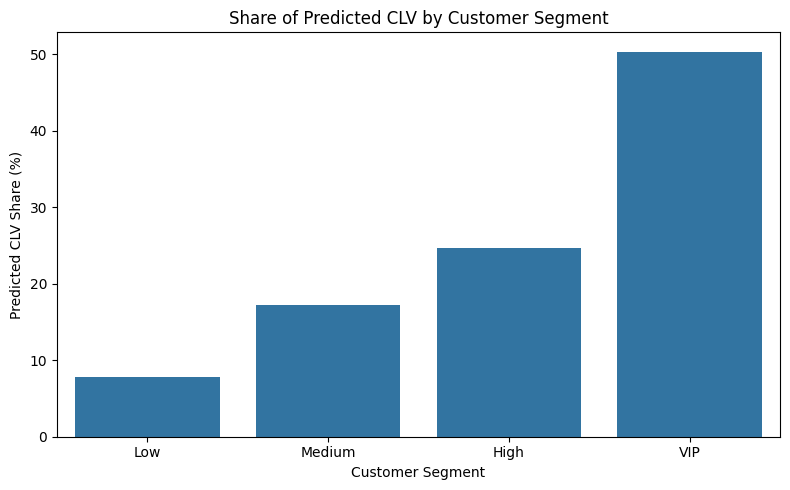

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=strategy_matrix,
    x="Value_Segment",
    y="Predicted_Value_Share_%",
    order=["Low", "Medium", "High", "VIP"]
)

plt.title("Share of Predicted CLV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Predicted CLV Share (%)")

plt.tight_layout()

plt.savefig(
    "../images/20_segment_value_concentration.png"
)

plt.show()

### 7.2 Average Predicted Value by Segment

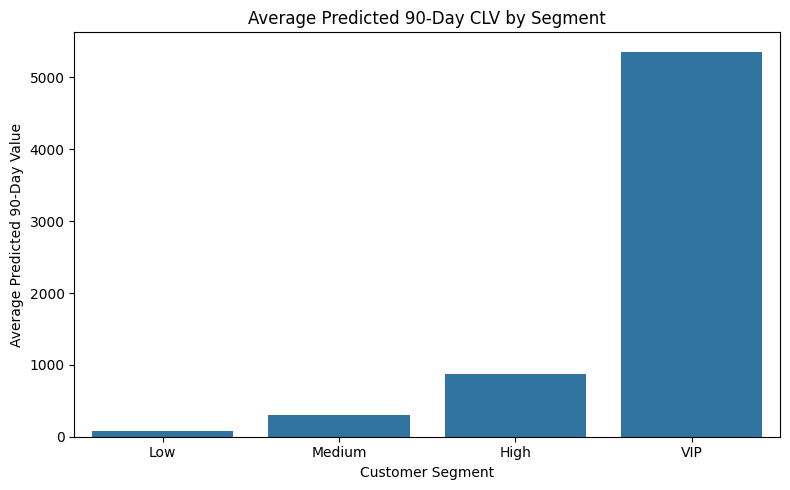

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_value,
    x="Value_Segment",
    y="Average_Predicted_Value",
    order=["Low", "Medium", "High", "VIP"]
)

plt.title("Average Predicted 90-Day CLV by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Predicted 90-Day Value")

plt.tight_layout()

plt.savefig(
    "../images/21_segment_average_value.png"
)

plt.show()

## 8. Final Customer Strategy Matrix

In [25]:
final_strategy_matrix = pd.DataFrame({
    "Segment": [
        "VIP",
        "High",
        "Medium",
        "Low"
    ],
    "Priority": [
        "Critical",
        "High",
        "Medium",
        "Low"
    ],
    "Primary_Goal": [
        "Retain high-value customers",
        "Increase customer value",
        "Increase engagement and repeat purchases",
        "Maintain efficiently"
    ],
    "Recommended_Strategy": [
        "Personalised retention, loyalty rewards, priority service, proactive engagement",
        "Cross-sell, upsell, loyalty incentives, targeted promotions",
        "Repeat-purchase reminders, product recommendations, moderate promotions",
        "Automated campaigns, lower-cost promotions, limited high-touch activity"
    ]
})

final_strategy_matrix

,Segment,Priority,Primary_Goal,Recommended_Strategy
0,VIP,Critical,Retain high-value customers,"Personalised retention, loyalty rewards, prior..."
1,High,High,Increase customer value,"Cross-sell, upsell, loyalty incentives, target..."
2,Medium,Medium,Increase engagement and repeat purchases,"Repeat-purchase reminders, product recommendat..."
3,Low,Low,Maintain efficiently,"Automated campaigns, lower-cost promotions, li..."


## 9. Marketing & Retention Action Plan

The customer value segments will be linked to specific marketing and retention actions.

The actions are based on each segment's predicted value, historical purchasing behaviour, and business priority.

### 9.1 Segment Action Plan

In [26]:
action_plan = pd.DataFrame({
    "Segment": [
        "VIP",
        "High",
        "Medium",
        "Low"
    ],
    "Priority": [
        "Critical",
        "High",
        "Medium",
        "Low"
    ],
    "Primary_Objective": [
        "Retain and protect high-value customers",
        "Increase value and move customers toward VIP",
        "Increase engagement and repeat purchasing",
        "Maintain efficiently and identify reactivation opportunities"
    ],
    "Recommended_Actions": [
        "Personalised offers, loyalty rewards, priority service, proactive retention",
        "Cross-sell, upsell, loyalty incentives, targeted promotions",
        "Product recommendations, repeat-purchase reminders, moderate promotions",
        "Automated campaigns, low-cost promotions, targeted reactivation"
    ],
    "Suggested_Channel": [
        "Email, loyalty programme, direct outreach",
        "Email, personalised promotions, loyalty programme",
        "Email, product recommendations, automated campaigns",
        "Automated email, lower-cost digital campaigns"
    ]
})

action_plan

,Segment,Priority,Primary_Objective,Recommended_Actions,Suggested_Channel
0,VIP,Critical,Retain and protect high-value customers,"Personalised offers, loyalty rewards, priority...","Email, loyalty programme, direct outreach"
1,High,High,Increase value and move customers toward VIP,"Cross-sell, upsell, loyalty incentives, target...","Email, personalised promotions, loyalty programme"
2,Medium,Medium,Increase engagement and repeat purchasing,"Product recommendations, repeat-purchase remin...","Email, product recommendations, automated camp..."
3,Low,Low,Maintain efficiently and identify reactivation...,"Automated campaigns, low-cost promotions, targ...","Automated email, lower-cost digital campaigns"


### 9.2 Recommended KPIs

In [27]:
action_plan["Primary_KPI"] = [
    "VIP retention rate and repeat purchase rate",
    "Conversion to VIP and increase in average order value",
    "Repeat purchase rate and purchase frequency",
    "Reactivation rate and cost per reactivated customer"
]

action_plan

,Segment,Priority,Primary_Objective,Recommended_Actions,Suggested_Channel,Primary_KPI
0,VIP,Critical,Retain and protect high-value customers,"Personalised offers, loyalty rewards, priority...","Email, loyalty programme, direct outreach",VIP retention rate and repeat purchase rate
1,High,High,Increase value and move customers toward VIP,"Cross-sell, upsell, loyalty incentives, target...","Email, personalised promotions, loyalty programme",Conversion to VIP and increase in average orde...
2,Medium,Medium,Increase engagement and repeat purchasing,"Product recommendations, repeat-purchase remin...","Email, product recommendations, automated camp...",Repeat purchase rate and purchase frequency
3,Low,Low,Maintain efficiently and identify reactivation...,"Automated campaigns, low-cost promotions, targ...","Automated email, lower-cost digital campaigns",Reactivation rate and cost per reactivated cus...


## 10. 90-Day Business Action Plan

The CLV segments can be used as the starting point for a phased 90-day customer strategy.

In [28]:
action_timeline = pd.DataFrame({
    "Period": [
        "Days 1-30",
        "Days 31-60",
        "Days 61-90"
    ],
    "Focus": [
        "Prepare and launch",
        "Test and measure",
        "Scale and improve"
    ],
    "Main_Actions": [
        "Load customer segments into marketing systems, identify VIP customers, prepare segment-specific campaigns",
        "Run targeted campaigns by segment, monitor KPIs, compare customer response across groups",
        "Scale the strongest campaigns, adjust weak campaigns, refresh customer segments using updated CLV predictions"
    ],
    "Main_Goal": [
        "Build the process",
        "Learn what works",
        "Improve resource allocation"
    ]
})

action_timeline

,Period,Focus,Main_Actions,Main_Goal
0,Days 1-30,Prepare and launch,"Load customer segments into marketing systems,...",Build the process
1,Days 31-60,Test and measure,"Run targeted campaigns by segment, monitor KPI...",Learn what works
2,Days 61-90,Scale and improve,"Scale the strongest campaigns, adjust weak cam...",Improve resource allocation


## 11. Resource Allocation Strategy

Marketing effort should not be distributed equally across all customers.

The predicted CLV concentration suggests that higher-value customer groups should receive greater attention, while lower-value customers should be managed more efficiently.

In [29]:
resource_strategy = pd.DataFrame({
    "Segment": [
        "VIP",
        "High",
        "Medium",
        "Low"
    ],
    "Marketing_Intensity": [
        "Very High",
        "High",
        "Medium",
        "Low"
    ],
    "Recommended_Approach": [
        "High-touch retention and loyalty",
        "Targeted growth and value expansion",
        "Automated engagement with selected offers",
        "Low-cost and automated marketing"
    ]
})

resource_strategy

,Segment,Marketing_Intensity,Recommended_Approach
0,VIP,Very High,High-touch retention and loyalty
1,High,High,Targeted growth and value expansion
2,Medium,Medium,Automated engagement with selected offers
3,Low,Low,Low-cost and automated marketing


### 11.1 Customer Strategy Matrix

In [30]:
strategy_visual = strategy_matrix[
    [
        "Value_Segment",
        "Customer_Share_%",
        "Predicted_Value_Share_%"
    ]
].copy()

strategy_visual = strategy_visual.set_index(
    "Value_Segment"
).reindex(
    ["Low", "Medium", "High", "VIP"]
)

strategy_visual

,Customer_Share_%,Predicted_Value_Share_%
Value_Segment,,
Low,50.009468,7.829438
Medium,29.994319,17.146962
High,14.997160,24.707023
VIP,4.999053,50.316577


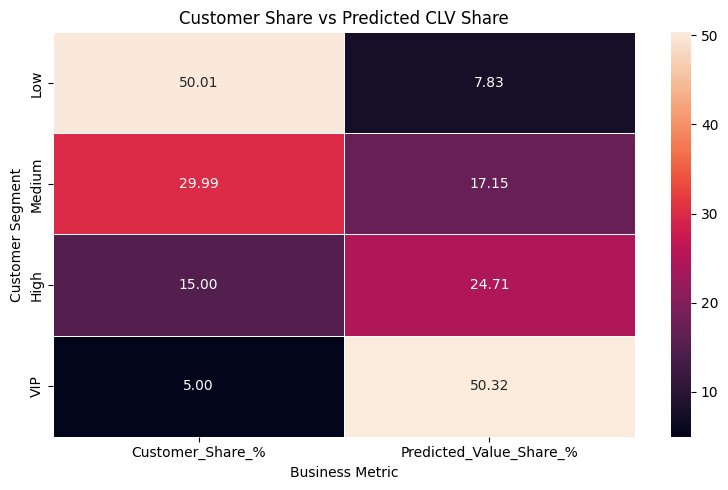

In [31]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    strategy_visual,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Customer Share vs Predicted CLV Share")
plt.xlabel("Business Metric")
plt.ylabel("Customer Segment")

plt.tight_layout()

plt.savefig(
    "../images/22_customer_strategy_matrix.png"
)

plt.show()

## 12. Immediate Business Priorities

In [32]:
immediate_priorities = pd.DataFrame({
    "Priority": [
        1,
        2,
        3,
        4
    ],
    "Action": [
        "Protect VIP customers",
        "Grow High-value customers",
        "Reactivate valuable inactive customers",
        "Manage Low-value customers efficiently"
    ],
    "Reason": [
        "5% of customers represent 50.32% of predicted future value",
        "High-value customers represent another 24.71% of predicted value",
        "Higher recency is associated with lower predicted CLV",
        "50.01% of customers represent only 7.83% of predicted value"
    ]
})

immediate_priorities

,Priority,Action,Reason
0,1,Protect VIP customers,5% of customers represent 50.32% of predicted ...
1,2,Grow High-value customers,High-value customers represent another 24.71% ...
2,3,Reactivate valuable inactive customers,Higher recency is associated with lower predic...
3,4,Manage Low-value customers efficiently,50.01% of customers represent only 7.83% of pr...


## 13. Final Executive Summary

### Business Problem

The project was developed to predict future customer value from retail transaction data and use those predictions to support customer retention and marketing resource allocation.

### What Was Done

The project combined transaction data cleaning, customer-level feature engineering, future CLV target creation, regression modelling, model tuning, interpretability analysis, customer value segmentation, and business strategy development.

### Key Finding

The final tuned Random Forest identified a strong concentration of customer value.

Only 5% of customers were classified as VIP, but they represented 50.32% of predicted future 90-day value and 49.29% of actual future value observed in the historical evaluation period.

### Main Customer Characteristics

VIP customers were generally more recent, purchased more frequently, spent substantially more historically, had higher average order values, purchased a wider range of products, and had longer customer tenure.

### Model Result

The tuned Random Forest improved on the original Random Forest:

- MAE: 576.78
- RMSE: 5622.81
- R²: 0.0350

The model was therefore used primarily as a customer prioritisation tool rather than an exact revenue forecast.

### Business Direction

The company should prioritise retention of VIP customers, develop High-value customers toward VIP status, use engagement and repeat-purchase strategies for Medium customers, and manage Low-value customers with lower-cost or automated campaigns.

## 14. Final Recommendations

### 1. Protect the VIP segment

The VIP segment should receive the strongest retention and loyalty attention because a small customer group represents a disproportionately large share of predicted future value.

### 2. Grow High-value customers

High-value customers should receive targeted cross-selling, upselling, and loyalty activity designed to increase purchase frequency and average order value.

### 3. Reactivate customers with declining engagement

Customers with high Recency should be considered for reactivation campaigns, especially when they still have meaningful historical spending or purchasing activity.

### 4. Manage Low-value customers efficiently

The Low segment represents half of the customer base but only 7.83% of predicted future value. These customers should mainly be reached through lower-cost and automated campaigns.

### 5. Refresh the CLV scores regularly

Customer behaviour changes over time, so the CLV predictions and segments should be refreshed periodically rather than treated as permanent customer labels.

## 15. Final Project Limitations

The CLV target is highly skewed, with many customers having zero future value and a smaller number of very high-value customers.

The final tuned model achieved an R² of 0.0350, so it explains only a small portion of the variation in future customer value.

The customer segments are based on model predictions and should therefore be used for prioritisation rather than treated as exact forecasts.

The actual-value comparison used in the segment analysis is retrospective because the future-period outcomes are already known in this historical dataset.

The project does not include campaign costs, customer acquisition costs, profit margins, or actual marketing response data, so the recommended resource allocation is directional rather than a detailed budget plan.

## 16. Final Project Conclusion

This project developed an end-to-end Customer Lifetime Value workflow from raw retail transactions to customer-level business recommendations.

The final analysis shows that customer value is highly concentrated. A small VIP group represents a large share of future value, while historical monetary value, recency, and purchasing behaviour are important signals in the model.

The final CLV framework can help the business prioritise retention, identify growth opportunities, target reactivation campaigns, and allocate marketing effort more efficiently.

The project is now complete from data preparation through modelling, interpretation, segmentation, and business strategy.

## 17. Final Project Status

✅ Part 01 - Data Understanding, Cleaning & Customer Behaviour Analysis

✅ Part 02 - Customer-Level Feature Engineering & CLV Target Creation

✅ Part 03 - CLV Prediction Model Development & Evaluation

✅ Part 04 - Model Tuning, Interpretability & Customer Value Analysis

✅ Part 05 - CLV Business Strategy & Final Executive Report

### Project Complete